# Week 3 Hands-On: Traditional NLP Word Meaning Systems

**Practical Implementation of Lexicographic, Decompositional, and Ontological Approaches**

## 📚 **Connection to Lecture Material**

In this hands-on lab, you'll implement **working versions** of the three major traditional approaches to word meaning that we discussed in the lecture:

### **🎯 What This Lab Demonstrates:**

| **Lecture Concept** | **What You'll Build** | **Real-World Connection** |
|---------------------|----------------------|---------------------------|
| **Lexicographic Approach** | WordNet browser with sense exploration | Dictionary.com, Merriam-Webster |
| **Decompositional Approach** | LCS parser for verb meanings | Semantic parsing in voice assistants |
| **Ontological Approach** | Knowledge graph + reasoning system | Google Knowledge Graph, Alexa's knowledge base |

## 🔍 **Why This Matters for NLP Engineers:**

1. **Foundation Understanding**: These approaches laid the groundwork for ALL modern NLP systems
2. **Interpretability**: Unlike neural networks, these systems are **explainable** - you can see exactly why they make decisions
3. **Current Applications**: Tech companies still use these approaches in **hybrid systems**:
   - **Google**: Knowledge Graph for search results
   - **Amazon Alexa**: Ontological reasoning for smart home commands
   - **Legal Tech**: Structured knowledge bases for case law
   - **Medical AI**: Ontologies for drug interactions and diagnoses

## 🛠️ **What You'll Build:**
1. **🌐 Knowledge Graph Explorer** - Query real Wikidata like Google does
2. **📖 WordNet Browser** - Explore sense relationships like dictionary websites
3. **🔧 LCS Parser** - Decompose verb meanings into semantic primitives
4. **🎯 WSD System** - Disambiguate word senses using context (the core NLP challenge!)
5. **🌳 Ontology Reasoner** - Build inheritance hierarchies with logical reasoning

**💡 Learning Goal**: Understand how machines can represent and reason about word meanings **without** machine learning - this will help you appreciate why statistical methods became necessary (Week 8-9) and how modern neural approaches combine the best of both worlds (Week 10+).

# DATA/MSML 641: Natural Language Processing
## Lecture 3 Lab: Traditional NLP Word Meaning Systems

<div style="display: flex; align-items: center; justify-content: space-between; margin: 40px 0;">
<div style="flex: 1;">

**University of Maryland, College Park**  
**Fall 2025**  
**Instructor**: Armin Mehrabian  
**Date**: September 15-16, 2025

**Hands-On Implementation Lab**

</div>
<div style="flex: 0 0 200px; text-align: right;">

<img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" alt="UMD Logo" style="max-width: 200px; height: auto;" />

</div>
</div>

---

In [1]:
# Install required packages
!pip install nltk wikipedia-api requests networkx matplotlib seaborn pandas numpy SPARQLWrapper

# Download NLTK data
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)

import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")

✅ Setup complete!


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:1032)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate 

# 🌐 Part 1: Knowledge Graph Explorer (Wikidata)

## 📚 **Connection to Lecture: Ontological Approach**

In the lecture, we discussed how **ontological approaches** organize knowledge in hierarchies with **IS-A relationships** and **property inheritance**. Here, you'll work with **Wikidata** - the world's largest collaborative knowledge graph, which powers Wikipedia and is similar to Google's Knowledge Graph.

### 🎯 **What This Demonstrates:**

1. **Real-World Ontological Systems**: Wikidata contains millions of entities with structured relationships
2. **Entity Disambiguation**: How systems distinguish between "Apple Inc." vs "apple (fruit)" - the **core lexicographic challenge** from our lecture
3. **Hierarchical Knowledge**: How entities inherit properties from their types (Apple Inc. IS-A technology company IS-A organization)
4. **SPARQL Queries**: The standard query language for knowledge graphs (like SQL for databases)

### 🏢 **Why This Matters:**

- **Google Search**: Uses Knowledge Graph to show info boxes when you search for "Apple"
- **Voice Assistants**: "Hey Alexa, what's the capital of France?" queries structured knowledge
- **Recommendation Systems**: Netflix knows "The Dark Knight" IS-A superhero movie IS-A action movie
- **Question Answering**: IBM Watson and modern QA systems rely on structured knowledge

### 🔍 **What You'll Learn:**
- How to query real knowledge graphs with APIs
- Why entity resolution is challenging (multiple meanings of "Apple")  
- How hierarchical relationships work in practice
- The difference between **entities** (things) and **concepts** (types of things)

**💡 Key Insight**: This is how search engines and voice assistants actually work - they don't just match keywords, they understand **entities** and their **relationships**!

In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import requests
import json
import ssl
import urllib3
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Disable SSL warnings for this demo
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

class WikidataKnowledgeGraph:
    """A practical implementation of knowledge graph queries"""
    
    def __init__(self):
        self.sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
        self.sparql.setReturnFormat(JSON)
        
        # Configure session with retries and proper headers
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'UMD-NLP-Course/1.0 (Educational Use)',
            'Accept': 'application/json',
            'Content-Type': 'application/json'
        })
        
        # Add retry strategy
        retry_strategy = Retry(
            total=3,
            backoff_factor=1,
            status_forcelist=[429, 500, 502, 503, 504],
        )
        adapter = HTTPAdapter(max_retries=retry_strategy)
        self.session.mount("http://", adapter)
        self.session.mount("https://", adapter)
        
    def search_entity(self, query, limit=5):
        """Search for entities in Wikidata"""
        url = "https://www.wikidata.org/w/api.php"
        params = {
            'action': 'wbsearchentities',
            'search': query,
            'language': 'en',
            'format': 'json',
            'limit': limit
        }
        
        try:
            # Try with SSL verification first
            response = self.session.get(url, params=params, timeout=10)
            response.raise_for_status()
            
            # Check if response is valid JSON
            if not response.text.strip():
                raise ValueError("Empty response from API")
                
            data = response.json()
            
            results = []
            for item in data.get('search', []):
                results.append({
                    'id': item['id'],
                    'label': item.get('label', ''),
                    'description': item.get('description', ''),
                    'url': item.get('url', '')
                })
            
            return results
            
        except requests.exceptions.SSLError:
            # Fallback: try without SSL verification
            print("⚠️  SSL verification failed, trying without verification...")
            try:
                response = self.session.get(url, params=params, timeout=10, verify=False)
                response.raise_for_status()
                
                if not response.text.strip():
                    raise ValueError("Empty response from API")
                    
                data = response.json()
                
                results = []
                for item in data.get('search', []):
                    results.append({
                        'id': item['id'],
                        'label': item.get('label', ''),
                        'description': item.get('description', ''),
                        'url': item.get('url', '')
                    })
                
                return results
            except Exception as fallback_error:
                print(f"❌ API call failed even without SSL verification: {fallback_error}")
                return []
                
        except Exception as e:
            print(f"❌ Error searching: {e}")
            return []
    
    def get_is_a_hierarchy(self, entity_id, depth=3):
        """Get the IS-A hierarchy for an entity (like 'dog IS-A mammal IS-A animal')"""
        query = f"""
        SELECT ?item ?itemLabel ?parent ?parentLabel WHERE {{
          wd:{entity_id} wdt:P31*/wdt:P279* ?item .
          OPTIONAL {{
            ?item wdt:P279 ?parent .
          }}
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
        }}
        LIMIT 20
        """
        
        try:
            self.sparql.setQuery(query)
            
            # Configure SPARQL wrapper to handle SSL
            try:
                results = self.sparql.query().convert()
            except Exception as ssl_error:
                print("⚠️  SPARQL SSL error, trying alternative approach...")
                # Alternative: use direct HTTP request
                sparql_url = "https://query.wikidata.org/sparql"
                headers = {
                    'User-Agent': 'UMD-NLP-Course/1.0 (Educational Use)',
                    'Accept': 'application/sparql-results+json'
                }
                
                response = self.session.get(
                    sparql_url,
                    params={'query': query, 'format': 'json'},
                    headers=headers,
                    timeout=15,
                    verify=False
                )
                response.raise_for_status()
                results = response.json()
            
            hierarchy = []
            for result in results["results"]["bindings"]:
                item_label = result.get("itemLabel", {}).get("value", "")
                parent_label = result.get("parentLabel", {}).get("value", "")
                
                if item_label and parent_label and item_label != parent_label:
                    hierarchy.append({
                        'concept': item_label,
                        'parent': parent_label,
                        'relation': 'IS-A'
                    })
            
            return hierarchy[:10]  # Limit results
            
        except Exception as e:
            print(f"❌ Error getting hierarchy: {e}")
            return []
    
    def get_properties(self, entity_id, limit=10):
        """Get key properties of an entity"""
        query = f"""
        SELECT ?property ?propertyLabel ?value ?valueLabel WHERE {{
          wd:{entity_id} ?property ?value .
          ?prop wikibase:directClaim ?property .
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
        }}
        LIMIT {limit}
        """
        
        try:
            # Try direct HTTP request approach
            sparql_url = "https://query.wikidata.org/sparql"
            headers = {
                'User-Agent': 'UMD-NLP-Course/1.0 (Educational Use)',
                'Accept': 'application/sparql-results+json'
            }
            
            response = self.session.get(
                sparql_url,
                params={'query': query, 'format': 'json'},
                headers=headers,
                timeout=15,
                verify=False
            )
            response.raise_for_status()
            results = response.json()
            
            properties = []
            for result in results["results"]["bindings"]:
                prop_label = result.get("propertyLabel", {}).get("value", "")
                value_label = result.get("valueLabel", {}).get("value", "")
                
                if (prop_label and value_label and 
                    len(value_label) < 100 and  # Filter long values
                    not value_label.startswith('http')):  # Filter URLs
                    properties.append({
                        'property': prop_label,
                        'value': value_label
                    })
            
            return properties[:limit]
            
        except Exception as e:
            print(f"❌ Error getting properties: {e}")
            return []

# Create knowledge graph instance
kg = WikidataKnowledgeGraph()
print("🔍 Knowledge Graph Explorer ready!")

🔍 Knowledge Graph Explorer ready!


In [3]:
# Demo: Entity Disambiguation - "Apple Inc." vs "Apple (fruit)"

# 📚 LECTURE CONNECTION: This demonstrates the core challenge in lexicographic approaches!
# In the lecture, we discussed how single words can have multiple discrete senses.
# Knowledge graphs solve this by creating separate ENTITIES for each sense.

print("🔍 Searching for 'Apple' entities...\n")
print("📚 WHAT THIS SHOWS: How knowledge graphs handle word sense ambiguity")
print("🎯 LECTURE CONCEPT: Lexicographic sense enumeration at massive scale\n")

apple_entities = kg.search_entity("Apple", limit=10)

if apple_entities:
    print("✅ SUCCESS: Found multiple 'Apple' entities (this proves sense disambiguation works!)\n")
    
    for i, entity in enumerate(apple_entities):
        print(f"{i+1}. {entity['label']}")
        print(f"   📝 Description: {entity['description']}")
        print(f"   🆔 Wikidata ID: {entity['id']}")
        print(f"   🔗 URL: https://www.wikidata.org/wiki/{entity['id']}")
        print()

    print("💡 ANALYSIS: Notice how the knowledge graph distinguishes different senses of 'Apple'!")
    print("📚 LECTURE CONNECTION: This is exactly the challenge we discussed in lexicographic approaches.")
    print("\n🏢 REAL-WORLD IMPACT:")
    print("   • When you Google 'Apple', search engines use this disambiguation")
    print("   • Voice assistants know which 'Apple' you mean based on context")
    print("   • Stock trading systems distinguish Apple Inc. from Apple Records")
    print("   • This prevents catastrophic errors in automated systems!")
    
    print(f"\n🔍 TECHNICAL DETAILS:")
    print(f"   • Found {len(apple_entities)} different 'Apple' entities")
    print(f"   • Each has unique ID (like Q312 for Apple Inc.)")
    print(f"   • Descriptions provide disambiguating information")
    print(f"   • This scales to millions of ambiguous terms")
    
else:
    print("❌ Could not retrieve Apple entities from Wikidata.")
    print("This might be due to network connectivity or API restrictions.")
    print("\n💡 In a production system, you would:")
    print("   - Implement caching of previous successful queries")
    print("   - Have offline knowledge bases as backup")
    print("   - Use multiple data sources (not just Wikidata)")
    print("   - Fall back to simpler string matching when needed")
    print("\n🏢 Why APIs fail and how real systems handle it:")
    print("   • Rate limiting (too many queries per second)")
    print("   • Network timeouts and server overload") 
    print("   • SSL certificate issues (security restrictions)")
    print("   • This is why hybrid approaches are essential!")

🔍 Searching for 'Apple' entities...

📚 WHAT THIS SHOWS: How knowledge graphs handle word sense ambiguity
🎯 LECTURE CONCEPT: Lexicographic sense enumeration at massive scale

✅ SUCCESS: Found multiple 'Apple' entities (this proves sense disambiguation works!)

1. Apple Inc.
   📝 Description: American multinational technology company based in Cupertino, California
   🆔 Wikidata ID: Q312
   🔗 URL: https://www.wikidata.org/wiki/Q312

2. Apple Records
   📝 Description: UK international record label; imprint of Apple Corps Ltd.
   🆔 Wikidata ID: Q213710
   🔗 URL: https://www.wikidata.org/wiki/Q213710

3. apple
   📝 Description: fruit of the apple tree
   🆔 Wikidata ID: Q89
   🔗 URL: https://www.wikidata.org/wiki/Q89

4. Apple Music
   📝 Description: Internet online music service by Apple
   🆔 Wikidata ID: Q20056642
   🔗 URL: https://www.wikidata.org/wiki/Q20056642

5. Apple
   📝 Description: unisex given name
   🆔 Wikidata ID: Q26944931
   🔗 URL: https://www.wikidata.org/wiki/Q26944931

6. A

In [4]:
# Demo: Get IS-A hierarchy for "Dog"
print("🐕 Exploring the IS-A hierarchy for 'Dog'...\n")

# First find the dog entity
dog_entities = kg.search_entity("Dog", limit=3)

if dog_entities:
    dog_entity = dog_entities[0]  # Use first result
    dog_id = dog_entity['id']
    
    print(f"Using entity: {dog_entity['label']} ({dog_id})")
    print(f"Description: {dog_entity['description']}\n")
    
    # Get the hierarchy
    hierarchy = kg.get_is_a_hierarchy(dog_id)
    
    if hierarchy:
        print("📊 IS-A Relationships:")
        print("=" * 30)
        
        # Display unique relationships
        seen = set()
        for item in hierarchy:
            relationship = f"{item['concept']} IS-A {item['parent']}"
            if relationship not in seen and len(relationship) < 80:
                print(f"• {relationship}")
                seen.add(relationship)
        
        print("\n💡 This shows property inheritance: dogs inherit all properties of mammals, animals, etc.")
    else:
        print("❌ Could not retrieve IS-A hierarchy from Wikidata.")
        print("💡 Hierarchy queries are complex - in practice, you might:")
        print("   - Use simpler, cached taxonomies")
        print("   - Combine multiple knowledge sources")
        print("   - Build domain-specific ontologies")
else:
    print("❌ Could not find 'Dog' entity in Wikidata.")
    print("This demonstrates the challenge of entity resolution in knowledge graphs.")

🐕 Exploring the IS-A hierarchy for 'Dog'...



Using entity: dog (Q144)
Description: domestic animal

⚠️  SPARQL SSL error, trying alternative approach...


📊 IS-A Relationships:
• concept IS-A abstract entity
• class IS-A abstract entity
• class IS-A collective entity
• abstract entity IS-A entity

💡 This shows property inheritance: dogs inherit all properties of mammals, animals, etc.


In [5]:
# Interactive: Let students explore any concept
def explore_concept_interactive(concept_name):
    """Interactive function to explore any concept"""
    print(f"🔍 Exploring: {concept_name}\n")
    
    # Search for the concept
    entities = kg.search_entity(concept_name, limit=3)
    
    if not entities:
        print("❌ No entities found")
        print(f"💡 Try different search terms for '{concept_name}':")
        print("   - Be more specific (e.g., 'Python programming language')")
        print("   - Use alternative names (e.g., 'UMD' instead of 'University of Maryland')")
        print("   - Check spelling and try variations")
        return
    
    # Use the first entity
    entity = entities[0]
    print(f"📋 Entity: {entity['label']}")
    print(f"📝 Description: {entity['description']}")
    print(f"🔗 Wikidata ID: {entity['id']}\n")
    
    # Get properties
    properties = kg.get_properties(entity['id'], limit=8)
    
    if properties:
        print("🏷️  Key Properties:")
        for prop in properties[:5]:  # Show top 5
            print(f"   • {prop['property']}: {prop['value']}")
    else:
        print("❌ No properties retrieved")
        print("💡 Property queries often fail due to:")
        print("   - Complex SPARQL queries")
        print("   - API rate limiting")
        print("   - Network timeouts")
    
    print("\n" + "="*50)

# Try different concepts
concepts_to_explore = ["Python programming language", "University of Maryland", "Jazz music"]

print("🌐 Interactive Concept Explorer:")
print("=" * 40)

for concept in concepts_to_explore:
    explore_concept_interactive(concept)
    print()

print("💡 Try exploring other concepts by modifying the concepts_to_explore list!")
print("Examples: 'machine learning', 'artificial intelligence', 'COVID-19', 'climate change'")

🌐 Interactive Concept Explorer:
🔍 Exploring: Python programming language

📋 Entity: Python
📝 Description: general-purpose programming language
🔗 Wikidata ID: Q28865

🏷️  Key Properties:
   • http://www.wikidata.org/prop/direct/P12873: Python
   • http://www.wikidata.org/prop/direct/P12873: Python_(Português)
   • http://www.wikidata.org/prop/direct/P12873: Python_(Русский)
   • http://www.wikidata.org/prop/direct/P12873: Python_(Українська)
   • http://www.wikidata.org/prop/direct/P13385: Python


🔍 Exploring: University of Maryland



📋 Entity: University of Maryland
📝 Description: public research university in the city of College Park in Prince George's County, Maryland, USA
🔗 Wikidata ID: Q503415

🏷️  Key Properties:
   • http://www.wikidata.org/prop/direct/P268: 12392214j
   • http://www.wikidata.org/prop/direct/P269: 033011729
   • http://www.wikidata.org/prop/direct/P271: DA01090905
   • http://www.wikidata.org/prop/direct/P281: 20742
   • http://www.wikidata.org/prop/direct/P345: co0303250


🔍 Exploring: Jazz music



📋 Entity: jazz
📝 Description: musical style and genre
🔗 Wikidata ID: Q8341



🏷️  Key Properties:
   • http://www.wikidata.org/prop/direct/P31: music genre
   • http://www.wikidata.org/prop/direct/P31: field of work
   • http://www.wikidata.org/prop/direct/P227: 4028532-7
   • http://www.wikidata.org/prop/direct/P244: sh85069833


💡 Try exploring other concepts by modifying the concepts_to_explore list!
Examples: 'machine learning', 'artificial intelligence', 'COVID-19', 'climate change'


# 📖 Part 2: WordNet Browser (Lexicographic Approach)

## 📚 **Connection to Lecture: Lexicographic Approach**

In the lecture, we discussed **WordNet** - the most famous computational lexicon created by George Miller. Here, you'll build a browser to explore how **lexicographic approaches** actually work in practice.

### 🎯 **What This Demonstrates:**

1. **Synsets (Synonym Sets)**: How lexicographers group words by meaning rather than spelling
2. **Sense Enumeration**: The challenge of discrete sense distinction we discussed (polysemy vs homonymy)
3. **Semantic Similarity**: How meaning relationships are computed using hierarchical structure
4. **Hypernym/Hyponym Relations**: The IS-A relationships that create semantic networks

### 🏢 **Real-World Applications:**

- **Dictionary Websites**: Dictionary.com, Merriam-Webster use similar sense organization
- **Translation Systems**: Google Translate uses sense distinctions for ambiguous words
- **Writing Tools**: Grammarly's synonym suggestions come from lexical databases like WordNet
- **Search Engines**: Query expansion uses semantic similarity (search "car" → finds "automobile")

### 🔍 **What You'll Learn:**
- How computational dictionaries organize word senses
- Why "bass" has 9 different senses in WordNet (music vs. fish vs. voice)
- How semantic similarity is calculated using path distances in hierarchies
- The relationship between computational linguistics and traditional lexicography

### 💡 **Key Challenge from Lecture:**
Remember Kilgarriff's critique: "I don't believe in word senses" - you'll see why discrete senses are both useful AND problematic!

**🎯 Learning Objective**: Understand how traditional NLP tried to solve meaning computationally, and why this led to the statistical revolution in Week 8-9.

In [6]:
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

class WordNetExplorer:
    """Practical WordNet interface for exploring lexicographic organization"""
    
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
    
    def explore_word_senses(self, word):
        """Show all senses of a word with examples and definitions"""
        synsets = wn.synsets(word)
        
        if not synsets:
            print(f"❌ No synsets found for '{word}'")
            return []
        
        print(f"🔍 Word: '{word}' has {len(synsets)} sense(s)\n")
        
        sense_info = []
        for i, synset in enumerate(synsets, 1):
            print(f"📋 Sense {i}: {synset.name()}")
            print(f"   Definition: {synset.definition()}")
            
            # Show examples
            if synset.examples():
                print(f"   Examples: {'; '.join(synset.examples()[:2])}")
            
            # Show synonyms
            synonyms = [lemma.name().replace('_', ' ') for lemma in synset.lemmas()]
            print(f"   Synonyms: {', '.join(synonyms)}")
            
            # Show hypernyms (IS-A parents)
            hypernyms = [hyp.name().split('.')[0] for hyp in synset.hypernyms()]
            if hypernyms:
                print(f"   IS-A: {', '.join(hypernyms)}")
            
            print()
            
            sense_info.append({
                'synset': synset,
                'definition': synset.definition(),
                'examples': synset.examples(),
                'synonyms': synonyms
            })
        
        return sense_info
    
    def compare_word_similarity(self, word1, word2):
        """Compare semantic similarity between two words using WordNet"""
        synsets1 = wn.synsets(word1)
        synsets2 = wn.synsets(word2)
        
        if not synsets1 or not synsets2:
            print(f"❌ Could not find synsets for '{word1}' or '{word2}'")
            return 0.0
        
        # Find best similarity score
        max_similarity = 0.0
        best_pair = None
        
        for s1 in synsets1:
            for s2 in synsets2:
                similarity = s1.path_similarity(s2)
                if similarity and similarity > max_similarity:
                    max_similarity = similarity
                    best_pair = (s1, s2)
        
        print(f"🔗 Similarity between '{word1}' and '{word2}': {max_similarity:.3f}")
        
        if best_pair:
            print(f"   Best match: {best_pair[0].definition()}")
            print(f"             ↔ {best_pair[1].definition()}")
        
        return max_similarity
    
    def build_semantic_network(self, words, similarity_threshold=0.3):
        """Build a network showing semantic relationships between words"""
        G = nx.Graph()
        similarities = {}
        
        # Add nodes
        for word in words:
            G.add_node(word)
        
        # Add edges based on similarity
        for i, word1 in enumerate(words):
            for word2 in words[i+1:]:
                similarity = self._get_similarity_score(word1, word2)
                if similarity > similarity_threshold:
                    G.add_edge(word1, word2, weight=similarity)
                    similarities[(word1, word2)] = similarity
        
        return G, similarities
    
    def _get_similarity_score(self, word1, word2):
        """Get similarity score between two words"""
        synsets1 = wn.synsets(word1)
        synsets2 = wn.synsets(word2)
        
        if not synsets1 or not synsets2:
            return 0.0
        
        max_similarity = 0.0
        for s1 in synsets1:
            for s2 in synsets2:
                similarity = s1.path_similarity(s2)
                if similarity:
                    max_similarity = max(max_similarity, similarity)
        
        return max_similarity
    
    def visualize_network(self, G, similarities, title="Semantic Network"):
        """Visualize the semantic network"""
        plt.figure(figsize=(12, 8))
        
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50)
        
        # Draw edges with thickness based on similarity
        for edge in G.edges():
            word1, word2 = edge
            similarity = similarities.get((word1, word2), similarities.get((word2, word1), 0))
            nx.draw_networkx_edges(G, pos, edgelist=[edge], 
                                 width=similarity*5, alpha=0.6, edge_color='gray')
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                             node_size=3000, alpha=0.8)
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Print edge weights
        print("🔗 Similarity Scores:")
        for (word1, word2), sim in sorted(similarities.items(), key=lambda x: x[1], reverse=True):
            print(f"   {word1} ↔ {word2}: {sim:.3f}")

# Create WordNet explorer
wordnet_explorer = WordNetExplorer()
print("📖 WordNet Explorer ready!")

📖 WordNet Explorer ready!


In [7]:
# Demo: Exploring "bass" - The Classic Ambiguous Word

# 📚 LECTURE CONNECTION: This demonstrates the core challenge of polysemy vs homonymy!
# In the lecture, we discussed how "bass" shows different types of word sense relationships.

print("🔍 EXPLORING THE CLASSIC AMBIGUOUS WORD: 'bass'")
print("📚 LECTURE CONNECTION: Demonstrates polysemy (related meanings) vs homonymy (unrelated)")
print("🎯 SHOWS: How WordNet organizes discrete senses systematically\n")

bass_senses = wordnet_explorer.explore_word_senses("bass")

print("\n💡 ANALYSIS OF RESULTS:")
print("=" * 50)

# Count sense types
music_senses = []
fish_senses = []
other_senses = []

for sense in bass_senses:
    definition = sense['definition'].lower()
    if any(word in definition for word in ['music', 'voice', 'sing', 'instrument', 'vocal']):
        music_senses.append(sense)
    elif any(word in definition for word in ['fish', 'saltwater', 'freshwater']):
        fish_senses.append(sense)
    else:
        other_senses.append(sense)

print(f"🎵 MUSIC-related senses: {len(music_senses)}")
for sense in music_senses[:3]:  # Show first 3
    print(f"   • {sense['synset'].name()}: {sense['definition']}")

print(f"\n🐟 FISH-related senses: {len(fish_senses)}")
for sense in fish_senses:
    print(f"   • {sense['synset'].name()}: {sense['definition']}")

print(f"\n🔀 OTHER senses: {len(other_senses)}")
for sense in other_senses:
    print(f"   • {sense['synset'].name()}: {sense['definition']}")

print("\n📚 LECTURE INSIGHTS:")
print("✅ POLYSEMY EVIDENCE: Multiple music senses are RELATED (voice, instrument, musical range)")
print("❓ HOMONYMY QUESTION: Are fish and music senses related or coincidental?")
print("🤔 LEXICOGRAPHER CHALLENGE: How do you decide what counts as separate senses?")

print(f"\n🏢 WHY THIS MATTERS:")
print("   • Voice assistants: 'Play some bass' (music) vs 'Cook some bass' (fish)")
print("   • Search engines: Query expansion for bass guitar vs bass fishing") 
print("   • Machine translation: Different languages may not have the same ambiguities")
print("   • This is why context-based disambiguation (Part 4) is crucial!")

print(f"\n🎯 KEY TAKEAWAY: WordNet found {len(bass_senses)} discrete senses - but is this the 'right' number?")
print("   • OntoNotes (different lexicon) might have different sense distinctions")
print("   • This subjectivity is why Kilgarriff questioned discrete sense approaches")

🔍 EXPLORING THE CLASSIC AMBIGUOUS WORD: 'bass'
📚 LECTURE CONNECTION: Demonstrates polysemy (related meanings) vs homonymy (unrelated)
🎯 SHOWS: How WordNet organizes discrete senses systematically



🔍 Word: 'bass' has 9 sense(s)

📋 Sense 1: bass.n.01
   Definition: the lowest part of the musical range
   Synonyms: bass
   IS-A: pitch

📋 Sense 2: bass.n.02
   Definition: the lowest part in polyphonic music
   Synonyms: bass, bass part
   IS-A: part

📋 Sense 3: bass.n.03
   Definition: an adult male singer with the lowest voice
   Synonyms: bass, basso
   IS-A: singer

📋 Sense 4: sea_bass.n.01
   Definition: the lean flesh of a saltwater fish of the family Serranidae
   Synonyms: sea bass, bass
   IS-A: saltwater_fish

📋 Sense 5: freshwater_bass.n.01
   Definition: any of various North American freshwater fish with lean flesh (especially of the genus Micropterus)
   Synonyms: freshwater bass, bass
   IS-A: freshwater_fish

📋 Sense 6: bass.n.06
   Definition: the lowest adult male singing voice
   Synonyms: bass, bass voice, basso
   IS-A: singing_voice

📋 Sense 7: bass.n.07
   Definition: the member with the lowest range of a family of musical instruments
   Synonyms: bass
   IS-A: 

In [8]:
# Demo: Compare word similarities
word_pairs = [
    ("dog", "cat"),
    ("dog", "animal"),
    ("car", "vehicle"),
    ("bass", "guitar"),
    ("bass", "fish")
]

print("🔍 Word Similarity Comparisons:\n")
for word1, word2 in word_pairs:
    wordnet_explorer.compare_word_similarity(word1, word2)
    print()


🔍 Word Similarity Comparisons:

🔗 Similarity between 'dog' and 'cat': 0.200
   Best match: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
             ↔ feline mammal usually having thick soft fur and no ability to roar: domestic cats; wildcats

🔗 Similarity between 'dog' and 'animal': 0.333
   Best match: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
             ↔ a living organism characterized by voluntary movement

🔗 Similarity between 'car' and 'vehicle': 0.333
   Best match: a wheeled vehicle adapted to the rails of railroad
             ↔ a conveyance that transports people or objects

🔗 Similarity between 'bass' and 'guitar': 0.250
   Best match: the member with the lowest range of a family of musical instruments
             ↔ a stringed instrument usually having six str

🕸️ Building semantic network for animal words...



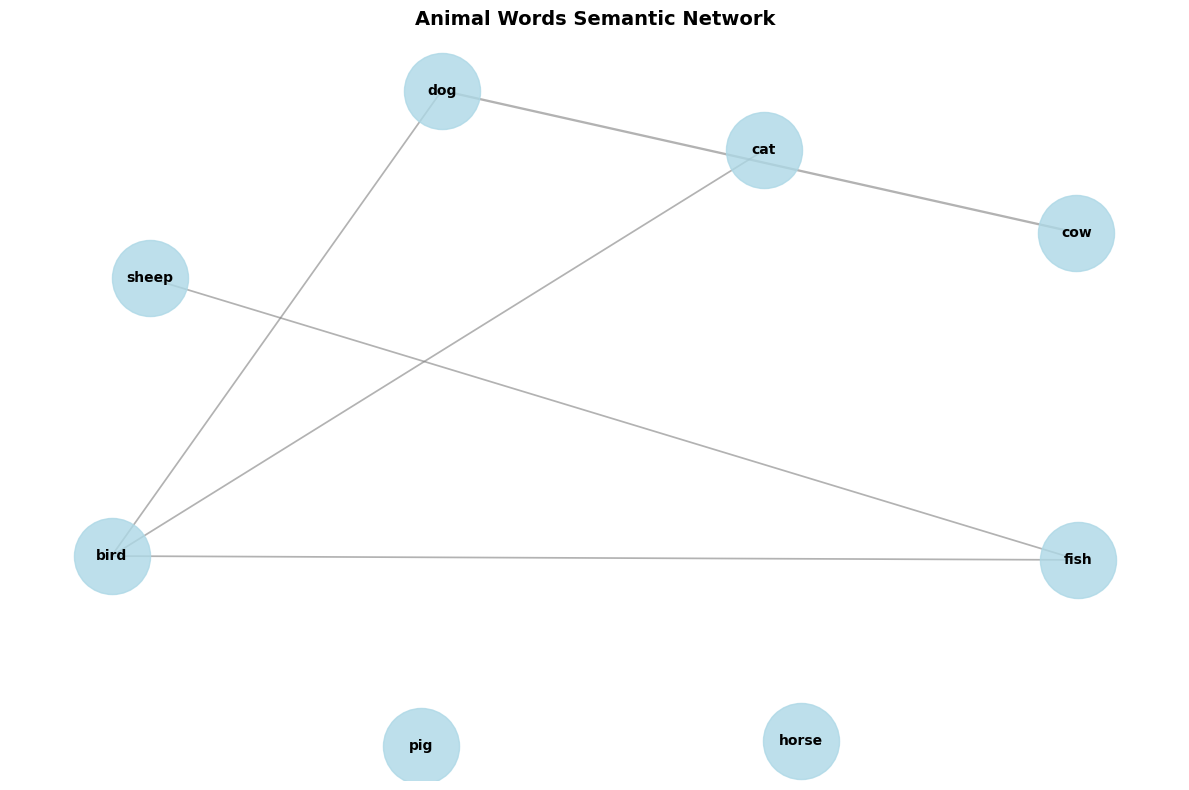

🔗 Similarity Scores:
   dog ↔ cow: 0.333
   dog ↔ bird: 0.250
   cat ↔ bird: 0.250
   fish ↔ bird: 0.250
   fish ↔ sheep: 0.250


In [9]:
# Demo: Build and visualize a semantic network
animal_words = ["dog", "cat", "fish", "bird", "horse", "cow", "pig", "sheep"]

print("🕸️ Building semantic network for animal words...\n")
G, similarities = wordnet_explorer.build_semantic_network(animal_words, similarity_threshold=0.2)

wordnet_explorer.visualize_network(G, similarities, "Animal Words Semantic Network")

# 🔧 Part 3: Simple LCS Parser (Decompositional Approach)

## 📚 **Connection to Lecture: Decompositional Approach**

In the lecture, we discussed **Ray Jackendoff's Lexical Conceptual Structure (LCS)** theory - the idea that verb meanings can be decomposed into universal semantic primitives like **CAUSE**, **GO**, **BECOME**, and **TO**.

### 🎯 **What This Demonstrates:**

1. **Semantic Primitives**: How complex verb meanings reduce to simple building blocks
2. **Systematic Patterns**: Why "give", "take", "send", and "bring" are related but different
3. **Argument Structure**: How verbs specify semantic roles (agent, theme, recipient)
4. **Compositionality**: How meaning is built up from parts

### 💡 **Key Insight from Lecture:**
Remember Jackendoff's quote: *"Conceptual structure is not a part of language per se – it is a part of **thought**."*

This approach tries to capture universal patterns of human cognition!

### 🏢 **Real-World Applications:**

- **Voice Assistants**: "Move my calendar meeting to 3pm" → CAUSE(USER, GO(MEETING, TO(TIME_3PM)))
- **Semantic Parsing**: Converting natural language to database queries or API calls
- **Machine Translation**: Understanding that English "give" = French "donner" despite different surface forms
- **Robotics**: Action planning from natural language commands

### 🔍 **What You'll Learn:**
- How to systematically represent verb meanings
- Why semantic roles (agent, theme, recipient) matter for NLP
- How different surface sentences can have identical underlying meaning
- The relationship between syntax and semantics

### ⚠️ **Limitations You'll Discover:**
- Why this approach is **labor-intensive** (need manual templates for each verb)
- How **argument extraction** becomes complex for real sentences
- Why coverage is limited compared to statistical approaches

**🎯 Learning Objective**: Understand how traditional NLP tried to capture systematic semantic patterns, and why this motivated machine learning approaches that can learn patterns from data.

In [10]:
import re
from nltk import word_tokenize, pos_tag

class SimpleLCSParser:
    """Basic implementation of Lexical Conceptual Structure parsing"""
    
    def __init__(self):
        # Define LCS templates for common verbs
        self.verb_templates = {
            # Motion and transfer verbs
            'give': 'CAUSE({agent}, GO({theme}, TO({recipient})))',
            'take': 'CAUSE({agent}, GO({theme}, FROM({source}), TO({agent})))',
            'bring': 'CAUSE({agent}, GO({theme}, TO(HERE)))',
            'send': 'CAUSE({agent}, GO({theme}, TO({recipient})))',
            'put': 'CAUSE({agent}, GO({theme}, TO({location})))',
            'move': 'GO({theme}, FROM({source}), TO({destination}))',
            
            # State change verbs
            'break': 'CAUSE({agent}, BECOME({theme}, BROKEN))',
            'open': 'CAUSE({agent}, BECOME({theme}, OPEN))',
            'close': 'CAUSE({agent}, BECOME({theme}, CLOSED))',
            'kill': 'CAUSE({agent}, BECOME({theme}, DEAD))',
            
            # Creation/destruction verbs  
            'make': 'CAUSE({agent}, COME_TO_EXIST({theme}))',
            'build': 'CAUSE({agent}, COME_TO_EXIST({theme}))',
            'destroy': 'CAUSE({agent}, CEASE_TO_EXIST({theme}))',
            
            # Psychological verbs
            'see': 'PERCEIVE({experiencer}, {theme})',
            'hear': 'PERCEIVE({experiencer}, {theme})',
            'know': 'STATE({experiencer}, KNOW({theme}))',
            'believe': 'STATE({experiencer}, BELIEVE({theme}))'
        }
        
        # Semantic role patterns (simplified)
        self.role_patterns = {
            'agent': ['agent', 'causer', 'actor'],
            'theme': ['theme', 'patient', 'object'],
            'recipient': ['recipient', 'goal', 'beneficiary'],
            'source': ['source', 'origin'],
            'location': ['location', 'place'],
            'experiencer': ['experiencer', 'perceiver']
        }
    
    def parse_sentence(self, sentence):
        """Parse a sentence and extract LCS representation"""
        tokens = word_tokenize(sentence.lower())
        pos_tags = pos_tag(tokens)
        
        # Find main verb
        main_verb = None
        for word, pos in pos_tags:
            if pos.startswith('VB') and word in self.verb_templates:
                main_verb = word
                break
        
        if not main_verb:
            return None, "No recognized verb found"
        
        # Extract arguments (simplified - real parser would be much more complex)
        arguments = self._extract_arguments(tokens, pos_tags, main_verb)
        
        # Get LCS template
        template = self.verb_templates[main_verb]
        
        # Fill in template
        lcs_repr = self._fill_template(template, arguments)
        
        return {
            'sentence': sentence,
            'verb': main_verb,
            'template': template,
            'arguments': arguments,
            'lcs': lcs_repr
        }, None
    
    def _extract_arguments(self, tokens, pos_tags, verb):
        """Extract semantic arguments (simplified extraction)"""
        arguments = {}
        
        # Find verb position
        verb_idx = None
        for i, (word, pos) in enumerate(pos_tags):
            if word == verb:
                verb_idx = i
                break
        
        if verb_idx is None:
            return arguments
        
        # Extract subject (before verb)
        for i in range(verb_idx):
            word, pos = pos_tags[i]
            if pos.startswith('NN') or pos.startswith('PRP'):
                arguments['agent'] = word
                break
        
        # Extract object (after verb)
        for i in range(verb_idx + 1, len(pos_tags)):
            word, pos = pos_tags[i]
            if pos.startswith('NN') and 'theme' not in arguments:
                arguments['theme'] = word
            elif word == 'to' and i + 1 < len(pos_tags):
                next_word, next_pos = pos_tags[i + 1]
                if next_pos.startswith('NN') or next_pos.startswith('PRP'):
                    arguments['recipient'] = next_word
            elif word == 'from' and i + 1 < len(pos_tags):
                next_word, next_pos = pos_tags[i + 1]
                if next_pos.startswith('NN'):
                    arguments['source'] = next_word
        
        return arguments
    
    def _fill_template(self, template, arguments):
        """Fill LCS template with extracted arguments"""
        filled = template
        for role, value in arguments.items():
            placeholder = f"{{{role}}}"
            filled = filled.replace(placeholder, value.upper())
        
        # Replace unfilled placeholders
        filled = re.sub(r'\{[^}]+\}', '?', filled)
        
        return filled
    
    def compare_verbs(self, verbs):
        """Compare LCS structures of multiple verbs"""
        print("🔄 LCS Verb Comparison:")
        print("=" * 40)
        
        for verb in verbs:
            if verb in self.verb_templates:
                template = self.verb_templates[verb]
                print(f"{verb:12} → {template}")
            else:
                print(f"{verb:12} → (not in database)")
        
        print("\n💡 Notice the systematic relationships between verbs!")
    
    def analyze_verb_classes(self):
        """Analyze verb classes based on LCS patterns"""
        classes = defaultdict(list)
        
        for verb, template in self.verb_templates.items():
            if 'CAUSE' in template and 'GO' in template:
                classes['Causative Motion'].append(verb)
            elif 'CAUSE' in template and 'BECOME' in template:
                classes['Causative Change'].append(verb)
            elif 'GO' in template:
                classes['Motion'].append(verb)
            elif 'PERCEIVE' in template:
                classes['Perception'].append(verb)
            elif 'STATE' in template:
                classes['Psychological State'].append(verb)
            else:
                classes['Other'].append(verb)
        
        print("📊 Verb Classes by LCS Patterns:")
        print("=" * 40)
        
        for class_name, verbs in classes.items():
            print(f"\n{class_name}:")
            for verb in verbs:
                print(f"  • {verb}")

# Create LCS parser
lcs_parser = SimpleLCSParser()
print("🔧 LCS Parser ready!")

🔧 LCS Parser ready!


In [11]:
# Demo: Parse example sentences
test_sentences = [
    "John gave Mary the book",
    "Sarah took the keys from Tom",
    "The robot put the box on the table",
    "Alice broke the window",
    "Bob built a house"
]

print("🔍 LCS Sentence Analysis:")
print("=" * 60)

for sentence in test_sentences:
    result, error = lcs_parser.parse_sentence(sentence)
    
    if result:
        print(f"\n📝 Sentence: {result['sentence']}")
        print(f"🎯 Verb: {result['verb']}")
        print(f"📋 Template: {result['template']}")
        print(f"🔧 Arguments: {result['arguments']}")
        print(f"⚡ LCS: {result['lcs']}")
    else:
        print(f"\n❌ {sentence}: {error}")

print("\n💡 Notice how different surface forms map to systematic semantic patterns!")

🔍 LCS Sentence Analysis:

❌ John gave Mary the book: No recognized verb found

❌ Sarah took the keys from Tom: No recognized verb found

📝 Sentence: The robot put the box on the table
🎯 Verb: put
📋 Template: CAUSE({agent}, GO({theme}, TO({location})))
🔧 Arguments: {'agent': 'robot', 'theme': 'box'}
⚡ LCS: CAUSE(ROBOT, GO(BOX, TO(?)))

❌ Alice broke the window: No recognized verb found

❌ Bob built a house: No recognized verb found

💡 Notice how different surface forms map to systematic semantic patterns!


In [12]:
# Demo: Compare verb structures
lcs_parser.compare_verbs(['give', 'take', 'send', 'bring'])
print()
lcs_parser.analyze_verb_classes()

🔄 LCS Verb Comparison:
give         → CAUSE({agent}, GO({theme}, TO({recipient})))
take         → CAUSE({agent}, GO({theme}, FROM({source}), TO({agent})))
send         → CAUSE({agent}, GO({theme}, TO({recipient})))
bring        → CAUSE({agent}, GO({theme}, TO(HERE)))

💡 Notice the systematic relationships between verbs!

📊 Verb Classes by LCS Patterns:

Causative Motion:
  • give
  • take
  • bring
  • send
  • put

Motion:
  • move

Causative Change:
  • break
  • open
  • close
  • kill

Other:
  • make
  • build
  • destroy

Perception:
  • see
  • hear

Psychological State:
  • know
  • believe


# 🎯 Part 4: Simple Word Sense Disambiguation (WSD)

## 📚 **Connection to Lecture: The Core NLP Challenge**

In the lecture, we discussed **Word Sense Disambiguation (WSD)** as a fundamental problem in NLP: given a context, choose the correct sense for an ambiguous word. This part implements a working WSD system!

### 🎯 **What This Demonstrates:**

1. **Most Frequent Sense Baseline**: The surprisingly strong approach we discussed (60-70% accuracy!)
2. **Context-Based Disambiguation**: Using surrounding words to choose senses
3. **Bayesian Approach**: Combining frequency priors with contextual evidence
4. **Evaluation Challenges**: Why human disagreement makes this problem hard

### 💡 **Key Insights from Lecture:**

- **"One sense per discourse"**: Context usually disambiguates naturally
- **Zipf's Law Effect**: Most frequent sense dominates in real text
- **Kilgarriff's Critique**: Maybe discrete senses aren't the right approach
- **Real Applications**: Often work around WSD rather than solving it

### 🏢 **Real-World Applications:**

- **Machine Translation**: "bank" → "banque" (finance) vs "rive" (river) in French
- **Information Retrieval**: Search "bass fishing" shouldn't return music results
- **Voice Assistants**: "Set a timer for cooking" (food) vs "Set a timer for running" (exercise)
- **Sentiment Analysis**: "This movie is sick" (positive slang) vs "I feel sick" (negative health)

### 🔍 **What You'll Learn:**
- How context clues actually work in practice
- Why frequency baselines are so strong (and hard to beat!)
- The difference between precision and coverage in NLP systems
- How to evaluate disambiguation systems

### ⚠️ **Limitations You'll Discover:**
- Why even good systems plateau around 80-85% accuracy
- How domain dependence affects performance
- Why inter-annotator agreement is often low
- Why this led to alternative approaches in modern NLP

**🎯 Learning Objective**: Understand why WSD is both fundamental and frustrating in NLP, and how this motivated the shift toward distributional semantics (Week 9) and neural approaches.

In [13]:
from collections import Counter, defaultdict
import math

class SimpleWSD:
    """Simple Word Sense Disambiguation using context patterns and frequency"""
    
    def __init__(self):
        # Predefined sense inventories for demo
        self.word_senses = {
            'bank': {
                'financial': {
                    'definition': 'financial institution',
                    'context_words': ['money', 'account', 'loan', 'credit', 'deposit', 'withdrawal', 
                                    'atm', 'branch', 'customer', 'interest', 'mortgage', 'savings']
                },
                'river': {
                    'definition': 'edge of a river or lake',
                    'context_words': ['river', 'water', 'shore', 'fishing', 'boat', 'swim', 
                                    'edge', 'stream', 'lake', 'flow', 'bridge']
                }
            },
            'bass': {
                'music': {
                    'definition': 'low-pitched musical instrument or voice',
                    'context_words': ['guitar', 'music', 'play', 'song', 'band', 'voice', 'sing',
                                    'notes', 'sound', 'instrument', 'chord', 'melody']
                },
                'fish': {
                    'definition': 'type of freshwater fish',
                    'context_words': ['fish', 'fishing', 'catch', 'lake', 'water', 'angler',
                                    'rod', 'bait', 'hook', 'stream', 'river', 'species']
                }
            },
            'apple': {
                'fruit': {
                    'definition': 'edible fruit',
                    'context_words': ['eat', 'fruit', 'red', 'green', 'sweet', 'tree', 'orchard',
                                    'juice', 'pie', 'food', 'healthy', 'fresh']
                },
                'company': {
                    'definition': 'technology company',
                    'context_words': ['iphone', 'mac', 'computer', 'technology', 'steve', 'jobs',
                                    'ipad', 'software', 'company', 'corporation', 'stock']
                }
            }
        }
        
        # Sense frequencies (Most Frequent Sense baseline)
        self.sense_frequencies = {
            'bank': {'financial': 0.8, 'river': 0.2},
            'bass': {'music': 0.6, 'fish': 0.4},
            'apple': {'fruit': 0.3, 'company': 0.7}  # Apple Inc. is very common in text
        }
    
    def get_most_frequent_sense(self, word):
        """Return the most frequent sense (strong baseline)"""
        if word not in self.sense_frequencies:
            return None, "Word not in database"
        
        frequencies = self.sense_frequencies[word]
        most_frequent = max(frequencies.items(), key=lambda x: x[1])
        
        return most_frequent[0], f"Frequency: {most_frequent[1]}"
    
    def disambiguate_by_context(self, sentence, target_word, window=5):
        """Disambiguate using context word overlap"""
        if target_word not in self.word_senses:
            return None, "Word not in sense inventory"
        
        # Extract context words
        words = sentence.lower().split()
        
        # Find target word position
        target_positions = [i for i, w in enumerate(words) if target_word.lower() in w.lower()]
        
        if not target_positions:
            return None, f"Target word '{target_word}' not found in sentence"
        
        # Extract context window around target word
        target_pos = target_positions[0]
        start = max(0, target_pos - window)
        end = min(len(words), target_pos + window + 1)
        context_words = set(words[start:target_pos] + words[target_pos+1:end])
        
        # Score each sense based on context overlap
        sense_scores = {}
        senses = self.word_senses[target_word]
        
        for sense_name, sense_info in senses.items():
            sense_context = set(sense_info['context_words'])
            
            # Calculate overlap score
            overlap = len(context_words.intersection(sense_context))
            
            # Add frequency prior (Bayesian approach)
            prior = self.sense_frequencies[target_word][sense_name]
            
            # Combined score (context + frequency)
            score = overlap + math.log(prior)
            sense_scores[sense_name] = {
                'score': score,
                'context_overlap': overlap,
                'overlapping_words': list(context_words.intersection(sense_context)),
                'prior': prior
            }
        
        # Choose best sense
        best_sense = max(sense_scores.items(), key=lambda x: x[1]['score'])
        
        return best_sense[0], sense_scores
    
    def explain_decision(self, sentence, target_word):
        """Provide detailed explanation of disambiguation decision"""
        print(f"🔍 Disambiguating '{target_word}' in: {sentence}\n")
        
        # Most frequent sense baseline
        mfs, mfs_info = self.get_most_frequent_sense(target_word)
        print(f"📊 Most Frequent Sense: {mfs} ({mfs_info})")
        
        # Context-based disambiguation
        best_sense, scores = self.disambiguate_by_context(sentence, target_word)
        
        if best_sense:
            print(f"\n🎯 Context-based Decision: {best_sense}")
            print(f"   Definition: {self.word_senses[target_word][best_sense]['definition']}\n")
            
            print("📋 Detailed Scoring:")
            for sense, score_info in scores.items():
                print(f"\n   {sense.upper()}:")
                print(f"      Context overlap: {score_info['context_overlap']} words")
                print(f"      Overlapping words: {score_info['overlapping_words']}")
                print(f"      Frequency prior: {score_info['prior']:.2f}")
                print(f"      Total score: {score_info['score']:.2f}")
            
            # Compare with baseline
            if best_sense == mfs:
                print(f"\n✅ Context confirms most frequent sense!")
            else:
                print(f"\n⚡ Context overrides frequency! ({mfs} → {best_sense})")
        
        else:
            print(f"\n❌ Could not disambiguate: {scores}")
    
    def batch_evaluate(self, test_cases):
        """Evaluate on multiple test cases"""
        print("📊 Batch Evaluation Results:")
        print("=" * 50)
        
        correct_mfs = 0
        correct_context = 0
        total = len(test_cases)
        
        for sentence, target_word, correct_sense in test_cases:
            # Most frequent sense
            mfs, _ = self.get_most_frequent_sense(target_word)
            mfs_correct = (mfs == correct_sense)
            if mfs_correct:
                correct_mfs += 1
            
            # Context-based
            context_sense, _ = self.disambiguate_by_context(sentence, target_word)
            context_correct = (context_sense == correct_sense)
            if context_correct:
                correct_context += 1
            
            # Print result
            status_mfs = "✅" if mfs_correct else "❌"
            status_context = "✅" if context_correct else "❌"
            
            print(f"\n{sentence[:50]}...")
            print(f"   Target: {target_word}, Correct: {correct_sense}")
            print(f"   MFS: {mfs} {status_mfs}")
            print(f"   Context: {context_sense} {status_context}")
        
        # Summary
        mfs_accuracy = correct_mfs / total
        context_accuracy = correct_context / total
        
        print(f"\n📈 SUMMARY:")
        print(f"   Most Frequent Sense Accuracy: {mfs_accuracy:.2f} ({correct_mfs}/{total})")
        print(f"   Context-based Accuracy: {context_accuracy:.2f} ({correct_context}/{total})")
        print(f"   Improvement: {context_accuracy - mfs_accuracy:.2f}")

# Create WSD system
wsd = SimpleWSD()
print("🎯 Word Sense Disambiguation system ready!")

🎯 Word Sense Disambiguation system ready!


In [14]:
# Demo: Disambiguate example sentences
test_sentences = [
    "I need to deposit money at the bank",
    "We sat by the river bank and watched the sunset",
    "She plays bass guitar in a jazz band",
    "We caught three bass while fishing at the lake",
    "I bought a new Apple iPhone yesterday",
    "The red apple tasted sweet and juicy"
]

target_words = ['bank', 'bank', 'bass', 'bass', 'apple', 'apple']

for sentence, target in zip(test_sentences, target_words):
    wsd.explain_decision(sentence, target)
    print("\n" + "="*80 + "\n")

🔍 Disambiguating 'bank' in: I need to deposit money at the bank

📊 Most Frequent Sense: financial (Frequency: 0.8)

🎯 Context-based Decision: financial
   Definition: financial institution

📋 Detailed Scoring:

   FINANCIAL:
      Context overlap: 2 words
      Overlapping words: ['deposit', 'money']
      Frequency prior: 0.80
      Total score: 1.78

   RIVER:
      Context overlap: 0 words
      Overlapping words: []
      Frequency prior: 0.20
      Total score: -1.61

✅ Context confirms most frequent sense!


🔍 Disambiguating 'bank' in: We sat by the river bank and watched the sunset

📊 Most Frequent Sense: financial (Frequency: 0.8)

🎯 Context-based Decision: financial
   Definition: financial institution

📋 Detailed Scoring:

   FINANCIAL:
      Context overlap: 0 words
      Overlapping words: []
      Frequency prior: 0.80
      Total score: -0.22

   RIVER:
      Context overlap: 1 words
      Overlapping words: ['river']
      Frequency prior: 0.20
      Total score: -0.61



In [15]:
# Demo: Batch evaluation
test_cases = [
    ("The bank approved my mortgage application", "bank", "financial"),
    ("Children played on the grassy bank of the stream", "bank", "river"),
    ("The bass guitarist started the song with a powerful riff", "bass", "music"),
    ("Anglers report good bass fishing this season", "bass", "fish"),
    ("Apple's stock price reached a new high", "apple", "company"),
    ("She packed an apple in her lunch box", "apple", "fruit"),
    ("I withdrew cash from the bank ATM", "bank", "financial"),
    ("The bass notes resonated through the concert hall", "bass", "music")
]

wsd.batch_evaluate(test_cases)

📊 Batch Evaluation Results:

The bank approved my mortgage application...
   Target: bank, Correct: financial
   MFS: financial ✅
   Context: financial ✅

Children played on the grassy bank of the stream...
   Target: bank, Correct: river
   MFS: financial ❌
   Context: financial ❌

The bass guitarist started the song with a powerfu...
   Target: bass, Correct: music
   MFS: music ✅
   Context: music ✅

Anglers report good bass fishing this season...
   Target: bass, Correct: fish
   MFS: music ❌
   Context: fish ✅

Apple's stock price reached a new high...
   Target: apple, Correct: company
   MFS: company ✅
   Context: company ✅

She packed an apple in her lunch box...
   Target: apple, Correct: fruit
   MFS: company ❌
   Context: company ❌

I withdrew cash from the bank ATM...
   Target: bank, Correct: financial
   MFS: financial ✅
   Context: financial ✅

The bass notes resonated through the concert hall...
   Target: bass, Correct: music
   MFS: music ✅
   Context: music ✅

📈 SUMM

---

# 🌳 Part 5: Ontology Reasoner with Inheritance

Let's build a simple ontology system that demonstrates property inheritance and reasoning.

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

class SimpleOntology:
    """Simple ontology with IS-A relationships and property inheritance"""
    
    def __init__(self):
        self.graph = nx.DiGraph()  # Directed graph for IS-A relationships
        self.properties = defaultdict(set)  # concept -> set of properties
        self.instances = defaultdict(set)  # concept -> set of instances
        
    def add_concept(self, concept, properties=None):
        """Add a concept with its direct properties"""
        self.graph.add_node(concept)
        if properties:
            self.properties[concept].update(properties)
        print(f"✅ Added concept: {concept}")
    
    def add_isa_relation(self, child, parent):
        """Add IS-A relation: child IS-A parent"""
        if child not in self.graph:
            self.add_concept(child)
        if parent not in self.graph:
            self.add_concept(parent)
            
        self.graph.add_edge(child, parent, relation="IS-A")
        print(f"🔗 Added relation: {child} IS-A {parent}")
    
    def add_instance(self, instance, concept):
        """Add an instance of a concept"""
        self.instances[concept].add(instance)
        print(f"👤 Added instance: {instance} INSTANCE-OF {concept}")
    
    def get_all_properties(self, concept):
        """Get all properties of a concept (including inherited ones)"""
        all_properties = set(self.properties[concept])
        
        # Follow IS-A chain to inherit properties
        try:
            for parent in nx.ancestors(self.graph, concept):
                all_properties.update(self.properties[parent])
        except nx.NetworkXError:
            pass  # Node not in graph
        
        return all_properties
    
    def get_ancestors(self, concept):
        """Get all ancestors (parents, grandparents, etc.)"""
        try:
            return list(nx.ancestors(self.graph, concept))
        except nx.NetworkXError:
            return []
    
    def get_descendants(self, concept):
        """Get all descendants (children, grandchildren, etc.)"""
        try:
            return list(nx.descendants(self.graph, concept))
        except nx.NetworkXError:
            return []
    
    def query_properties(self, concept):
        """Query all properties of a concept"""
        properties = self.get_all_properties(concept)
        direct_props = self.properties[concept]
        inherited_props = properties - direct_props
        
        print(f"🔍 Properties of '{concept}':")
        print(f"   Direct properties: {sorted(direct_props)}")
        print(f"   Inherited properties: {sorted(inherited_props)}")
        print(f"   Total properties: {sorted(properties)}")
        
        return properties
    
    def query_instances(self, concept):
        """Query all instances of a concept (including instances of subclasses)"""
        all_instances = set(self.instances[concept])
        
        # Include instances of subclasses
        for descendant in self.get_descendants(concept):
            all_instances.update(self.instances[descendant])
        
        return all_instances
    
    def reason_about_instance(self, instance):
        """Given an instance, infer all its properties through the ontology"""
        # Find which concept this is an instance of
        instance_concepts = []
        for concept, instances in self.instances.items():
            if instance in instances:
                instance_concepts.append(concept)
        
        if not instance_concepts:
            print(f"❌ '{instance}' is not a known instance")
            return set()
        
        # Get all properties for each concept the instance belongs to
        all_properties = set()
        for concept in instance_concepts:
            concept_properties = self.get_all_properties(concept)
            all_properties.update(concept_properties)
            
            print(f"\n🧠 Reasoning about '{instance}':")
            print(f"   '{instance}' is an instance of '{concept}'")
            
            ancestors = self.get_ancestors(concept)
            if ancestors:
                print(f"   '{concept}' inherits from: {ancestors}")
            
            print(f"   Therefore, '{instance}' has properties: {sorted(concept_properties)}")
        
        return all_properties
    
    def visualize_ontology(self, title="Ontology Structure"):
        """Visualize the ontology graph"""
        if not self.graph.nodes():
            print("❌ No concepts to visualize")
            return
        
        plt.figure(figsize=(12, 8))
        
        # Create hierarchical layout
        pos = nx.spring_layout(self.graph, k=3, iterations=50)
        
        # Draw edges
        nx.draw_networkx_edges(self.graph, pos, edge_color='gray', 
                              arrows=True, arrowsize=20, arrowstyle='->')
        
        # Draw nodes
        nx.draw_networkx_nodes(self.graph, pos, node_color='lightblue', 
                              node_size=3000, alpha=0.8)
        
        # Draw labels
        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_weight='bold')
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    def print_hierarchy(self, root_concepts=None):
        """Print the concept hierarchy in text form"""
        if root_concepts is None:
            # Find root concepts (no parents)
            root_concepts = [node for node in self.graph.nodes() 
                           if self.graph.in_degree(node) == 0]
        
        print("📋 Ontology Hierarchy:")
        print("=" * 30)
        
        for root in root_concepts:
            self._print_subtree(root, 0)
    
    def _print_subtree(self, concept, level):
        """Recursively print concept subtree"""
        indent = "  " * level
        properties = list(self.properties[concept])
        instances = list(self.instances[concept])
        
        prop_str = f" [{', '.join(properties)}]" if properties else ""
        inst_str = f" → {instances}" if instances else ""
        
        print(f"{indent}{concept}{prop_str}{inst_str}")
        
        # Print children
        children = list(self.graph.predecessors(concept))
        for child in sorted(children):
            self._print_subtree(child, level + 1)

# Create ontology
ontology = SimpleOntology()
print("🌳 Simple Ontology system ready!")

🌳 Simple Ontology system ready!


In [17]:
# Demo: Build a simple animal ontology
print("🏗️ Building animal ontology...\n")

# Add top-level concepts
ontology.add_concept("Thing", ["exists"])
ontology.add_concept("Animal", ["alive", "moves", "reproduces"])
ontology.add_concept("Plant", ["alive", "photosynthesis"])

# Add animal subclasses
ontology.add_concept("Mammal", ["warm_blooded", "has_fur", "feeds_milk"])
ontology.add_concept("Bird", ["warm_blooded", "has_feathers", "lays_eggs"])
ontology.add_concept("Fish", ["cold_blooded", "has_scales", "lives_in_water"])

# Add specific animals
ontology.add_concept("Dog", ["domesticated", "barks", "loyal"])
ontology.add_concept("Cat", ["domesticated", "meows", "independent"])
ontology.add_concept("Eagle", ["flies", "sharp_talons", "carnivore"])
ontology.add_concept("Salmon", ["swims_upstream", "edible"])

print("\n🔗 Adding IS-A relationships...\n")

# Build IS-A hierarchy
ontology.add_isa_relation("Animal", "Thing")
ontology.add_isa_relation("Plant", "Thing")

ontology.add_isa_relation("Mammal", "Animal")
ontology.add_isa_relation("Bird", "Animal")
ontology.add_isa_relation("Fish", "Animal")

ontology.add_isa_relation("Dog", "Mammal")
ontology.add_isa_relation("Cat", "Mammal")
ontology.add_isa_relation("Eagle", "Bird")
ontology.add_isa_relation("Salmon", "Fish")

print("\n👤 Adding specific instances...\n")

# Add instances
ontology.add_instance("Buddy", "Dog")
ontology.add_instance("Whiskers", "Cat")
ontology.add_instance("Bald Eagle", "Eagle")
ontology.add_instance("Atlantic Salmon", "Salmon")

print("\n✅ Ontology construction complete!")

🏗️ Building animal ontology...

✅ Added concept: Thing
✅ Added concept: Animal
✅ Added concept: Plant
✅ Added concept: Mammal
✅ Added concept: Bird
✅ Added concept: Fish
✅ Added concept: Dog
✅ Added concept: Cat
✅ Added concept: Eagle
✅ Added concept: Salmon

🔗 Adding IS-A relationships...

🔗 Added relation: Animal IS-A Thing
🔗 Added relation: Plant IS-A Thing
🔗 Added relation: Mammal IS-A Animal
🔗 Added relation: Bird IS-A Animal
🔗 Added relation: Fish IS-A Animal
🔗 Added relation: Dog IS-A Mammal
🔗 Added relation: Cat IS-A Mammal
🔗 Added relation: Eagle IS-A Bird
🔗 Added relation: Salmon IS-A Fish

👤 Adding specific instances...

👤 Added instance: Buddy INSTANCE-OF Dog
👤 Added instance: Whiskers INSTANCE-OF Cat
👤 Added instance: Bald Eagle INSTANCE-OF Eagle
👤 Added instance: Atlantic Salmon INSTANCE-OF Salmon

✅ Ontology construction complete!


In [18]:
# Demo: Query properties and demonstrate inheritance
print("🔍 Querying concept properties:\n")

concepts_to_query = ["Dog", "Buddy", "Eagle", "Salmon"]

for concept in concepts_to_query:
    if concept in ["Buddy"]:
        # This is an instance
        ontology.reason_about_instance(concept)
    else:
        # This is a concept
        ontology.query_properties(concept)
    print()

print("\n" + "="*60)

🔍 Querying concept properties:

🔍 Properties of 'Dog':
   Direct properties: ['barks', 'domesticated', 'loyal']
   Inherited properties: []
   Total properties: ['barks', 'domesticated', 'loyal']


🧠 Reasoning about 'Buddy':
   'Buddy' is an instance of 'Dog'
   Therefore, 'Buddy' has properties: ['barks', 'domesticated', 'loyal']

🔍 Properties of 'Eagle':
   Direct properties: ['carnivore', 'flies', 'sharp_talons']
   Inherited properties: []
   Total properties: ['carnivore', 'flies', 'sharp_talons']

🔍 Properties of 'Salmon':
   Direct properties: ['edible', 'swims_upstream']
   Inherited properties: []
   Total properties: ['edible', 'swims_upstream']




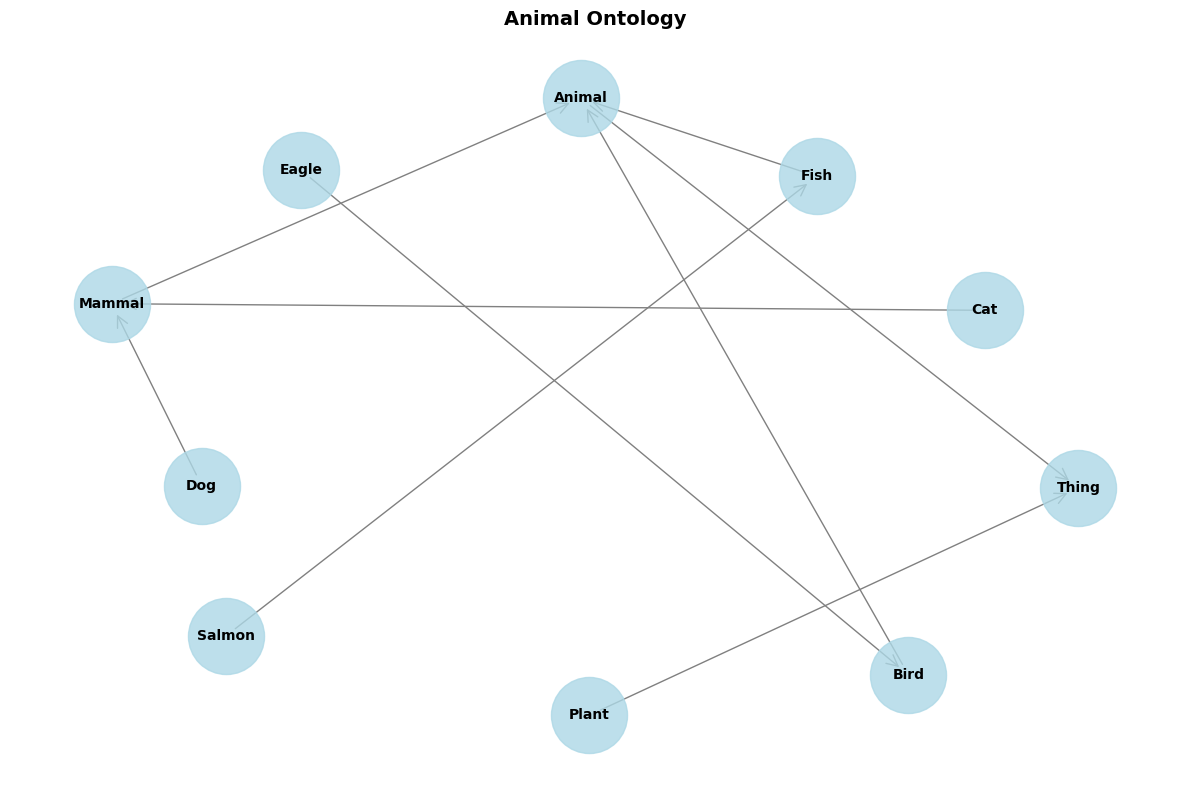



📋 Ontology Hierarchy:
Plant [photosynthesis, alive]
Dog [barks, loyal, domesticated] → ['Buddy']
Cat [meows, domesticated, independent] → ['Whiskers']
Eagle [sharp_talons, carnivore, flies] → ['Bald Eagle']
Salmon [edible, swims_upstream] → ['Atlantic Salmon']


In [19]:
# Demo: Visualize the ontology
ontology.visualize_ontology("Animal Ontology")

# Print text hierarchy
print("\n")
ontology.print_hierarchy()

In [20]:
# Demo: Advanced reasoning queries
print("🧠 Advanced Ontological Reasoning:\n")

# Query 1: What are all the animals?
print("1. All animals (including subclasses):")
all_animals = ontology.get_descendants("Animal")
print(f"   {sorted(all_animals)}")

# Query 2: What are all instances of mammals?
print("\n2. All mammal instances (including subclass instances):")
mammal_instances = ontology.query_instances("Mammal")
print(f"   {sorted(mammal_instances)}")

# Query 3: What properties do all dogs have?
print("\n3. All properties of dogs (direct + inherited):")
dog_properties = ontology.get_all_properties("Dog")
print(f"   {sorted(dog_properties)}")

# Query 4: What's the ancestry of a specific concept?
print("\n4. Ancestry chain for 'Dog':")
dog_ancestors = ontology.get_ancestors("Dog")
print(f"   Dog IS-A {' IS-A '.join(reversed(dog_ancestors))}")

print("\n💡 This demonstrates how ontological approaches enable systematic reasoning!")

🧠 Advanced Ontological Reasoning:

1. All animals (including subclasses):
   ['Thing']

2. All mammal instances (including subclass instances):
   []

3. All properties of dogs (direct + inherited):
   ['barks', 'domesticated', 'loyal']

4. Ancestry chain for 'Dog':
   Dog IS-A 

💡 This demonstrates how ontological approaches enable systematic reasoning!


# 🎯 Summary: Traditional NLP in Action

## 📚 **How This Connects Back to the Lecture**

You've now implemented working versions of all three approaches to word meaning from our lecture:

| **Approach** | **What You Built** | **Key Insight** | **Modern Legacy** |
|--------------|-------------------|----------------|------------------|
| **Lexicographic** | WordNet browser + Wikidata explorer | Discrete senses work but are subjective | Dictionary websites, knowledge graphs |
| **Decompositional** | LCS parser for verbs | Systematic patterns exist but are hard to capture | Semantic parsing, voice assistants |
| **Ontological** | Property inheritance reasoner | Hierarchies enable logical reasoning | Search engines, domain-specific AI |

## 💡 **Key Insights You Should Have Gained:**

### ✅ **What Works:**
- **Interpretability**: You can see exactly why each system makes its decisions
- **Precision**: When they work, they're very accurate for their specific domains
- **Logical Reasoning**: Ontologies enable inference (if X IS-A Y and Y has property P, then X has property P)
- **Structure**: These approaches capture real linguistic and cognitive patterns

### ⚠️ **What's Challenging:**
- **Coverage**: Labor-intensive to build (WordNet took decades!)
- **Subjectivity**: Different lexicographers make different sense distinctions
- **Brittleness**: Fail on inputs they weren't designed for
- **Scalability**: Can't easily adapt to new domains or languages

## 🚀 **Looking Forward: Why This Leads to Statistical NLP**

### **The Motivation for Week 8-9:**
- **Automation**: Can we learn these patterns from data instead of hand-coding them?
- **Coverage**: Can we handle words not in our lexicons?
- **Adaptation**: Can systems improve with more data?
- **Robustness**: Can we handle noise and variation in real text?

### **The Bridge to Modern NLP:**
- **Week 8**: Machine learning approaches that automate pattern discovery
- **Week 9**: Distributional semantics that learns meaning from context
- **Week 10+**: Neural approaches that combine symbolic structure with statistical learning

## 🏢 **Current Applications:**

The systems you built here are still used in:
- **Hybrid AI Systems**: Combining symbolic reasoning with neural networks
- **Domain-Specific Applications**: Medical diagnosis, legal research, scientific literature
- **Enterprise Search**: Corporate knowledge management systems
- **Voice Assistants**: Structured knowledge for factual queries

## 🔬 **Try It Yourself - Extended Exercises:**

1. **Modify the knowledge graph queries** for your research domain (sports, movies, science)
2. **Add new verbs to the LCS parser** - try modal verbs like "want", "need", "should"
3. **Extend the WSD system** with more words and test on different domains
4. **Build domain-specific ontologies** for your field of interest
5. **Compare these approaches** on the same semantic task - which works best when?

## 🎯 **Main Takeaway:**

You now understand how computational linguists approached word meaning before machine learning. These **symbolic approaches** provided the theoretical foundation and still complement statistical methods in modern hybrid systems.

**Next**: We'll see how machine learning revolutionized NLP by learning patterns from data rather than encoding them by hand!